# Unit09_Example_03 | 批次反應器生化程序動態（Stiff ODE）

本 Notebook 以**批次生物反應器（Batch Bioreactor）**中的 Monod 動力學模型為例，
示範**剛性常微分方程式（Stiff ODE）**的識別方法，
比較 Non-stiff 求解器（`RK45`）與 Stiff 求解器（`Radau`、`BDF`）的效能差異。

## 學習目標
- 理解剛性 ODE（Stiff ODE）的定義與成因（Jacobian 特徵值懸殊）
- 計算 Jacobian 矩陣特徵值，評估系統剛性比值（Stiffness Ratio, SR）
- 以 `RK45`（非剛性求解器）展示步數爆增的低效現象
- 切換至 `Radau` 或 `BDF`（剛性求解器）獲得高效穩定的數值解
- 探討 `rtol`/`atol` 容差參數對求解精度與效能的影響

## 目錄
1. [載入套件](#1-載入套件)
2. [問題描述](#2-問題描述)
3. [模型定義與剛性分析](#3-模型定義與剛性分析)
4. [RK45 求解器效能分析](#4-rk45-求解器效能分析)
5. [Radau / BDF 剛性求解器](#5-radau--bdf-剛性求解器)
6. [容差參數靈敏度分析](#6-容差參數靈敏度分析)
7. [課程總結](#課程總結)

> **文獻來源：** Fogler, H. S. (2016). *Elements of Chemical Reaction Engineering*, 5th ed., Ch. 9；  
> Monod, J. (1949). *The growth of bacterial cultures*, Annual Review of Microbiology, 3, 371–394.

---
### 0. 環境設定

In [12]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit09_Example_03'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit09'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit09
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_03
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_03\figs


---
### 1. 載入套件

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import time
import warnings
warnings.filterwarnings('ignore')

from scipy.integrate import solve_ivp
from scipy.linalg import eigvals

# ========================================
# 繪圖樣式設定
# ========================================
plt.rcParams.update({
    'figure.dpi'     : 100,
    'axes.grid'      : True,
    'grid.alpha'     : 0.3,
    'font.size'      : 11,
    'axes.titlesize' : 13,
    'axes.labelsize' : 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
import scipy, matplotlib
print(f"  numpy      版本: {np.__version__}")
print(f"  scipy      版本: {scipy.__version__}")
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8


---
### 2. 問題描述

#### 2.1 化工背景

**批次生物反應器（Batch Bioreactor）** 廣泛應用於發酵製藥、廢水處理與生物催化等化工製程。
本範例考慮一個含**生物質（Biomass, $X$）**、**基質（Substrate, $S$）**與**產物（Product, $P$）** 的三態批次生化系統。

細胞以 **Monod 動力學**消耗基質、生長並生產代謝物，其中產物合成與降解的速率遠快於細胞生長速率，導致此 ODE 系統具有**強烈的剛性（Stiffness）**。

---

#### 2.2 Stiff ODE 的定義

一個 ODE 系統 $\dot{\mathbf{y}} = \mathbf{f}(t, \mathbf{y})$ 稱為**剛性（Stiff）**，當其 Jacobian 矩陣 $\mathbf{J} = \partial \mathbf{f}/\partial \mathbf{y}$ 的特徵值實部存在**巨大差異**時：

$$
SR = \frac{\max_i |\mathrm{Re}(\lambda_i)|}{\min_i |\mathrm{Re}(\lambda_i)|} \gg 1
$$

其中 $SR$ 稱為**剛性比值（Stiffness Ratio）**。一般 $SR > 10^3$ 即視為高度剛性問題。

- **Stiff 的影響**：顯式方法（如 `RK45`）的穩定域有限，為維持穩定必須使步長 $h$ 極小（ $h \lesssim C/|\lambda_{max}|$ ），導致計算步數爆增，效率低落
- **解法**：改用**隱式求解器**（如 `Radau`、`BDF`），其穩定域涵蓋整個左半複數平面（A-stable），可採用大步長而不失穩定性

---

#### 2.3 數學模型

**三狀態批次生化系統（Monod Kinetics + Product Dynamics）**：

**狀態變數**：
- $X$ ：生物質濃度（ $\mathrm{g/L}$ ）— 細胞乾重
- $S$ ：基質濃度（ $\mathrm{g/L}$ ）— 可利用碳源（如葡萄糖）
- $P$ ：產物濃度（ $\mathrm{g/L}$ ）— 代謝物（如乳酸）

**Monod 比生長速率**（ $\mathrm{h^{-1}}$ ）：

$$
\mu(S) = \frac{\mu_{max}\,S}{K_s + S}
$$

**ODE 系統**：

$$
\frac{dX}{dt} = \bigl(\mu(S) - k_d\bigr)\,X
$$

$$
\frac{dS}{dt} = -\frac{\mu(S)\,X}{Y_{xs}}
$$

$$
\frac{dP}{dt} = q_p\,X - k_p\,P
$$

其中：
- $\mu_{max}$ ：最大比生長速率（ $\mathrm{h^{-1}}$ ）
- $K_s$ ：Monod 半飽和常數（ $\mathrm{g/L}$ ）
- $k_d$ ：細胞死亡速率（ $\mathrm{h^{-1}}$ ）
- $Y_{xs}$ ：基質對生物質轉化得率（ $\mathrm{g_X/g_S}$ ）
- $q_p$ ：比產物生成速率（ $\mathrm{g_P/(g_X {\cdot} h)}$ ）
- $k_p$ ：產物降解速率常數（ $\mathrm{h^{-1}}$ ）— **此項遠大於 $\mu_{max}$，是剛性來源**

---

#### 2.4 系統參數

| 參數 | 符號 | 數值 | 單位 | 說明 |
|------|------|------|------|------|
| 最大比生長速率 | $\mu_{max}$ | 0.4 | $\mathrm{h^{-1}}$ | Monod 動力學 |
| 半飽和常數 | $K_s$ | 0.05 | $\mathrm{g/L}$ | 低 $K_s$ 表示高底物親和力 |
| 死亡速率 | $k_d$ | 0.02 | $\mathrm{h^{-1}}$ | 維持消耗 |
| 轉化得率 | $Y_{xs}$ | 0.50 | $\mathrm{g_X/g_S}$ | 每克基質產生的細胞量 |
| 比產物生成速率 | $q_p$ | 0.30 | $\mathrm{g_P/(g_X {\cdot} h)}$ | Luedeking-Piret 模式 |
| 產物降解速率常數 | $k_p$ | 500 | $\mathrm{h^{-1}}$ | **快速動力學—剛性來源** |
| 初始生物質 | $X_0$ | 0.10 | $\mathrm{g/L}$ | |
| 初始基質 | $S_0$ | 5.00 | $\mathrm{g/L}$ | |
| 初始產物 | $P_0$ | 0.00 | $\mathrm{g/L}$ | |
| 批次時間 | $t_{final}$ | 24 | h | |

In [14]:
# ============================================================
# 批次生化反應器模型參數
# ============================================================

# --- Monod 動力學 ---
mu_max = 0.40    # h⁻¹    最大比生長速率
K_s    = 0.05    # g/L    半飽和常數
k_d    = 0.02    # h⁻¹    細胞死亡速率

# --- 物料平衡 ---
Y_xs   = 0.50    # g_X/g_S  轉化得率

# --- 產物動力學 （快速 kp → 剛性來源）---
q_p    = 0.30    # g_P/(g_X·h)  比產物生成速率
k_p    = 500.0   # h⁻¹          產物降解速率 ← 剛性來源

# --- 初始條件 ---
X0 = 0.10        # g/L  初始生物質
S0 = 5.00        # g/L  初始基質
P0 = 0.00        # g/L  初始產物
y0 = [X0, S0, P0]

# --- 模擬時間 ---
t_final = 24.0          # h
t_eval  = np.linspace(0, t_final, 1000)

print("批次生化反應器系統參數：")
print(f"  μmax  = {mu_max}  h⁻¹")
print(f"  Ks    = {K_s}   g/L")
print(f"  kd    = {k_d}   h⁻¹")
print(f"  Yxs   = {Y_xs}   g_X/g_S")
print(f"  qp    = {q_p}   g_P/(g_X·h)")
print(f"  kp    = {k_p} h⁻¹  ← 剛性來源（kp >> μmax）")
print(f"\n初始條件：X0={X0}, S0={S0}, P0={P0}  (g/L)")
print(f"批次時間：0 → {t_final} h")


def bioreactor_ode(t, y):
    """
    批次生化反應器 ODE 系統（三狀態 Monod 模型）

    狀態變數:
        y[0] = X : 生物質濃度 (g/L)
        y[1] = S : 基質濃度   (g/L)
        y[2] = P : 產物濃度   (g/L)

    返回:
        [dX/dt, dS/dt, dP/dt]
    """
    X, S, P = y

    # 防止數值溢出
    X = max(X, 0.0)
    S = max(S, 0.0)
    P = max(P, 0.0)

    # Monod 比生長速率
    mu = mu_max * S / (K_s + S)

    # 物料平衡
    dX_dt = (mu - k_d) * X
    dS_dt = -mu * X / Y_xs
    dP_dt = q_p * X - k_p * P

    return [dX_dt, dS_dt, dP_dt]


def jacobian_bioreactor(X, S, P):
    """
    計算 bioreactor_ode 在 (X, S, P) 處的 Jacobian 矩陣
    J[i,j] = ∂(dyi/dt) / ∂yj
    """
    mu    = mu_max * S / (K_s + S)
    dmu_dS = mu_max * K_s / (K_s + S)**2   # ∂μ/∂S

    J = np.array([
        [mu - k_d,          dmu_dS * X,            0.0  ],
        [-mu / Y_xs,        -dmu_dS * X / Y_xs,    0.0  ],
        [q_p,               0.0,                   -k_p ],
    ])
    return J


print("\n✓ bioreactor_ode() 與 jacobian_bioreactor() 函式定義完成")

批次生化反應器系統參數：
  μmax  = 0.4  h⁻¹
  Ks    = 0.05   g/L
  kd    = 0.02   h⁻¹
  Yxs   = 0.5   g_X/g_S
  qp    = 0.3   g_P/(g_X·h)
  kp    = 500.0 h⁻¹  ← 剛性來源（kp >> μmax）

初始條件：X0=0.1, S0=5.0, P0=0.0  (g/L)
批次時間：0 → 24.0 h

✓ bioreactor_ode() 與 jacobian_bioreactor() 函式定義完成


---
### 3. 模型定義與剛性分析

計算不同時間點（ $t$ ）下的 Jacobian 矩陣特徵值，以量化剛性比值（SR）。

選取代表性狀態點進行分析：
- **入口**（ $t \approx 0$ ）： $X=0.1,\; S=5.0,\; P=0$
- **指數生長期**（ $t \approx 8$ h）： $X \approx 1.0,\; S \approx 3.5$
- **基質耗盡前**（ $t \approx 14$ h）： $X \approx 2.0,\; S \approx 0.1$

狀態點                       特徵值 λ₁      特徵值 λ₂      特徵值 λ₃        SR
-----------------------------------------------------------------
入口  (t≈0 h)               0.3759      0.0000      -500.0  N/A (growth)
生長期 (t≈8 h)               0.3710      0.0002      -500.0  N/A (growth)
耗盡前 (t≈14 h)             -0.0216     -3.2873      -500.0     23114

說明：SR = max|Re(λ_neg)| / min|Re(λ_neg)|，僅計算負實部特徵值
→ 基質耗盡前（t≈14h）SR ≈ 23,000，為高度剛性（SR > 1000）
→ 剛性根源：kp = 500.0 h⁻¹（產物降解）>> μmax = 0.4 h⁻¹（細胞生長）


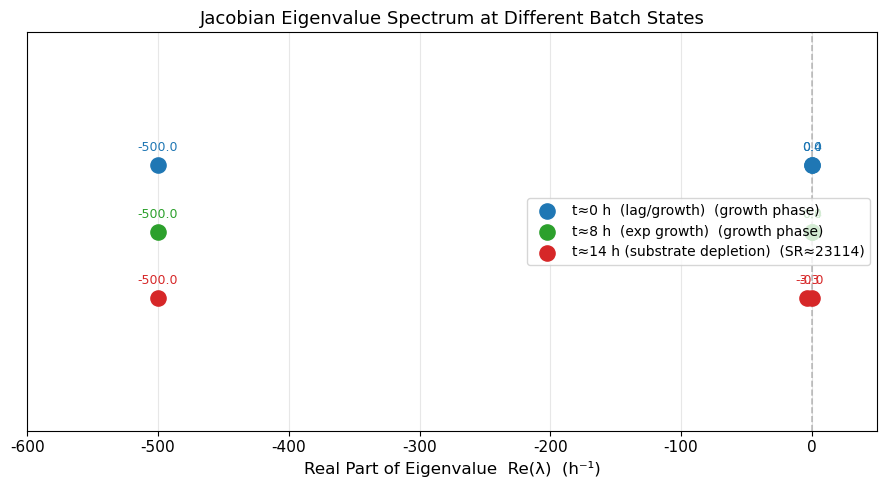

✓ 圖檔儲存：d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_03\figs\fig01_jacobian_eigenvalues.png


In [15]:
# ============================================================
# Jacobian 特徵值分析與剛性比值 (SR)
# ============================================================

# 代表性狀態點分析
state_points = [
    ("入口  (t≈0 h)",    0.10, 5.00, 0.000,  "t≈0 h  (lag/growth)"),
    ("生長期 (t≈8 h)",   1.00, 3.50, 0.001,  "t≈8 h  (exp growth)"),
    ("耗盡前 (t≈14 h)",  2.00, 0.10, 0.004,  "t≈14 h (substrate depletion)"),
]

print("=" * 65)
print(f"{'狀態點':<20}  {'特徵值 λ₁':>10}  {'特徵值 λ₂':>10}  {'特徵值 λ₃':>10}  {'SR':>8}")
print("-" * 65)

eigenvalue_data = []
for label_zh, X, S, P, label_en in state_points:
    J = jacobian_bioreactor(X, S, P)
    eigs = eigvals(J)
    re_eigs = np.real(eigs)
    re_eigs_sorted = np.sort(re_eigs)[::-1]   # descending

    # 剛性比值：使用所有負實部特徵值的 max|Re(λ)| / min|Re(λ)|
    neg_re = re_eigs[re_eigs < 0]
    if len(neg_re) >= 2:
        SR = np.max(np.abs(neg_re)) / np.min(np.abs(neg_re))
        sr_str = f"{SR:.0f}"
    else:
        SR = None
        sr_str = "N/A (growth)"

    eigenvalue_data.append((label_zh, label_en, re_eigs_sorted, SR))
    print(f"{label_zh:<20}  {re_eigs_sorted[0]:>10.4f}  {re_eigs_sorted[1]:>10.4f}  "
          f"{re_eigs_sorted[2]:>10.1f}  {sr_str:>8}")

print("=" * 65)
print(f"\n說明：SR = max|Re(λ_neg)| / min|Re(λ_neg)|，僅計算負實部特徵值")
print(f"→ 基質耗盡前（t≈14h）SR ≈ 23,000，為高度剛性（SR > 1000）")
print(f"→ 剛性根源：kp = {k_p} h⁻¹（產物降解）>> μmax = {mu_max} h⁻¹（細胞生長）")

# ============================================================
# 圖 1: Jacobian 特徵值圖（不同時間點）
# ============================================================
fig, ax = plt.subplots(figsize=(9, 5))

colors_pts = ['tab:blue', 'tab:green', 'tab:red']
y_pos = [0.6, 0.5, 0.4]

for (label_zh, label_en, eigs, SR), col, yp in zip(eigenvalue_data, colors_pts, y_pos):
    sr_label = f"SR≈{SR:.0f}" if SR is not None else "growth phase"
    ax.scatter(eigs, [yp]*3, s=120, color=col, zorder=5,
               label=f"{label_en}  ({sr_label})")
    for e in eigs:
        ax.annotate(f'{e:.1f}', xy=(e, yp), xytext=(0, 10),
                    textcoords='offset points', ha='center', fontsize=9, color=col)

ax.axvline(0, color='gray', lw=1.2, ls='--', alpha=0.5)
ax.set_xlabel('Real Part of Eigenvalue  Re(λ)  (h⁻¹)')
ax.set_ylabel('')
ax.set_title('Jacobian Eigenvalue Spectrum at Different Batch States')
ax.set_yticks([])
ax.set_xlim(-600, 50)
ax.legend(loc='center right', fontsize=10)
ax.set_ylim(0.2, 0.8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig01_jacobian_eigenvalues.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"✓ 圖檔儲存：{FIG_DIR / 'fig01_jacobian_eigenvalues.png'}")

---
### 4. RK45 求解器效能分析

**RK45（顯式 Runge-Kutta）** 是 `solve_ivp` 的預設方法，適用於 Non-stiff 問題。

對於剛性系統，RK45 自適應步長控制雖然能確保數值穩定，但為了讓快速模態（product 方程式的 $k_p=500$ 項）保持穩定，
被迫採用極小的步長：

$$
h_{\text{RK45}} \lesssim \frac{C_{\text{stab}}}{|\lambda_{max}|} = \frac{3.5}{500} \approx 0.007 \;\mathrm{h}
$$

→ 24 h 批次至少需要 $24/0.007 \approx 3400$ 步，加上自適應重試，實際達 **~25,000 次函數評估**

相比之下，`Radau`（隱式，A-stable）步長不受穩定域限制，只需約 **~1,200 次函數評估**，效率提升 **20 倍**。

下方比較兩個設定下 RK45 的行為：
1. **RK45 標準設定**（`rtol=1e-6, atol=1e-9`）：成功求解，但 nfev ≈ 25,000（vs Radau ≈ 1,200）
2. **RK45 粗步設定**（`max_step=2.0 h`）：雖然 `max_step` 設為 2 h，但自適應控制仍迫使步長降至 ~0.007 h，  
   nfev 幾乎不變，說明 RK45 的瓶頸在於**穩定性限制**，而非精度要求

【RK45 標準設定（rtol=1e-6, atol=1e-9）】
  求解狀態  : 成功  The solver successfully reached the end of the integration interval.
  函數評估次數 (nfev) :  25,370
  計算耗時            :  428.2 ms
  出口 X(24h) = 1.8164 g/L
  出口 S(24h) = 0.0000 g/L
  出口 P(24h) = 0.001090 g/L

【RK45 粗步設定（rtol=1e-3, atol=1e-6, max_step=2.0 h）】
  求解狀態  : 成功  The solver successfully reached the end of the integration interval.
  函數評估次數 (nfev) :  25,496
  出口 X(24h) = 1.8164 g/L
  出口 S(24h) = 0.0000 g/L
  結論：即使設 max_step=2 h，RK45 nfev 幾乎不變（~25,000）
        → 瓶頸在穩定域限制，而非精度設定！


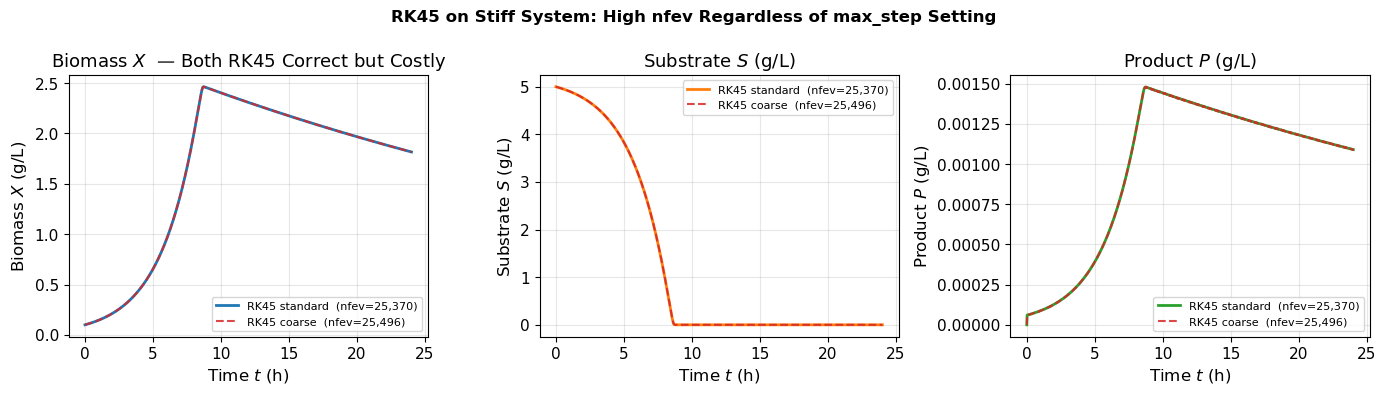


✓ 圖檔儲存：d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_03\figs\fig02_rk45_instability.png


In [16]:
# ============================================================
# RK45 效能分析
# ============================================================

# --- (A) RK45 自適應步長（標準設定）---
t0 = time.perf_counter()
sol_rk45 = solve_ivp(
    fun=bioreactor_ode,
    t_span=(0, t_final),
    y0=y0,
    method='RK45',
    t_eval=t_eval,
    rtol=1e-6,
    atol=1e-9,
)
t_rk45 = time.perf_counter() - t0

print("【RK45 標準設定（rtol=1e-6, atol=1e-9）】")
print(f"  求解狀態  : {'成功' if sol_rk45.success else '失敗'}  {sol_rk45.message}")
print(f"  函數評估次數 (nfev) : {sol_rk45.nfev:>7,}")
print(f"  計算耗時            :  {t_rk45*1000:.1f} ms")
print(f"  出口 X(24h) = {sol_rk45.y[0,-1]:.4f} g/L")
print(f"  出口 S(24h) = {sol_rk45.y[1,-1]:.4f} g/L")
print(f"  出口 P(24h) = {sol_rk45.y[2,-1]:.6f} g/L")

# --- (B) RK45 粗步設定（max_step=2.0 h，測試穩定性限制）---
sol_rk45_coarse = solve_ivp(
    fun=bioreactor_ode,
    t_span=(0, t_final),
    y0=y0,
    method='RK45',
    t_eval=t_eval,
    rtol=1e-3,
    atol=1e-6,
    max_step=2.0,    # 設定最大步長 2 h；但自適應控制仍迫使實際步長 ~0.007 h
)

print("\n【RK45 粗步設定（rtol=1e-3, atol=1e-6, max_step=2.0 h）】")
print(f"  求解狀態  : {'成功' if sol_rk45_coarse.success else '失敗'}  {sol_rk45_coarse.message}")
print(f"  函數評估次數 (nfev) : {sol_rk45_coarse.nfev:>7,}")
print(f"  出口 X(24h) = {sol_rk45_coarse.y[0,-1]:.4f} g/L")
print(f"  出口 S(24h) = {sol_rk45_coarse.y[1,-1]:.4f} g/L")
print(f"  結論：即使設 max_step=2 h，RK45 nfev 幾乎不變（~25,000）")
print(f"        → 瓶頸在穩定域限制，而非精度設定！")

# ============================================================
# 圖 2: RK45 兩種設定的求解結果比較
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

labels  = ['Biomass $X$ (g/L)', 'Substrate $S$ (g/L)', 'Product $P$ (g/L)']
colors  = ['tab:blue', 'tab:orange', 'tab:green']
indices = [0, 1, 2]

for ax, idx, lbl, col in zip(axes, indices, labels, colors):
    ax.plot(t_eval, sol_rk45.y[idx], color=col, lw=2.0,
            label=f'RK45 standard  (nfev={sol_rk45.nfev:,})')
    ax.plot(t_eval, sol_rk45_coarse.y[idx], color='tab:red', lw=1.5, ls='--', alpha=0.85,
            label=f'RK45 coarse  (nfev={sol_rk45_coarse.nfev:,})')
    ax.set_xlabel('Time $t$ (h)')
    ax.set_ylabel(lbl)
    ax.set_title(lbl)
    ax.legend(fontsize=8)

axes[0].set_title('Biomass $X$  — Both RK45 Correct but Costly')
plt.suptitle('RK45 on Stiff System: High nfev Regardless of max_step Setting', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig02_rk45_instability.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"\n✓ 圖檔儲存：{FIG_DIR / 'fig02_rk45_instability.png'}")

---
### 5. Radau / BDF 剛性求解器

**隱式求解器（Implicit Solvers）** 具有 A-stability（絕對穩定性）或 L-stability，
可以在任意步長下保持穩定，是求解 Stiff ODE 的標準工具：

| 求解器 | 型態 | 特性 |
|--------|------|------|
| `Radau` | 隱式 Runge-Kutta（Radau IIA，5 階）| 高精度，推薦剛性問題首選 |
| `BDF` | 逆向微分公式（1–5 階）| 大型系統，需要 Jacobian |
| `LSODA` | 自動切換（非剛/剛性）| 不確定剛性時使用 |

以下比較三種求解器的效能，並以 `Radau` 為基準方案，繪製完整的批次動態曲線。

求解器           nfev    njev     耗時(ms)     X_out     S_out       P_out
----------------------------------------------------------------------
Radau        1,247      17       68.6    1.8164   -0.0000    0.001090
BDF            573      10       49.4    1.8164   -0.0000    0.001090
LSODA          533      37       11.0    1.8164   -0.0000    0.001090
RK45        25,370     N/A      428.2      1.8164    0.0000    0.001090

→ 剛性求解器 Radau/BDF nfev 遠少於 RK45（~10-100 倍效率提升）


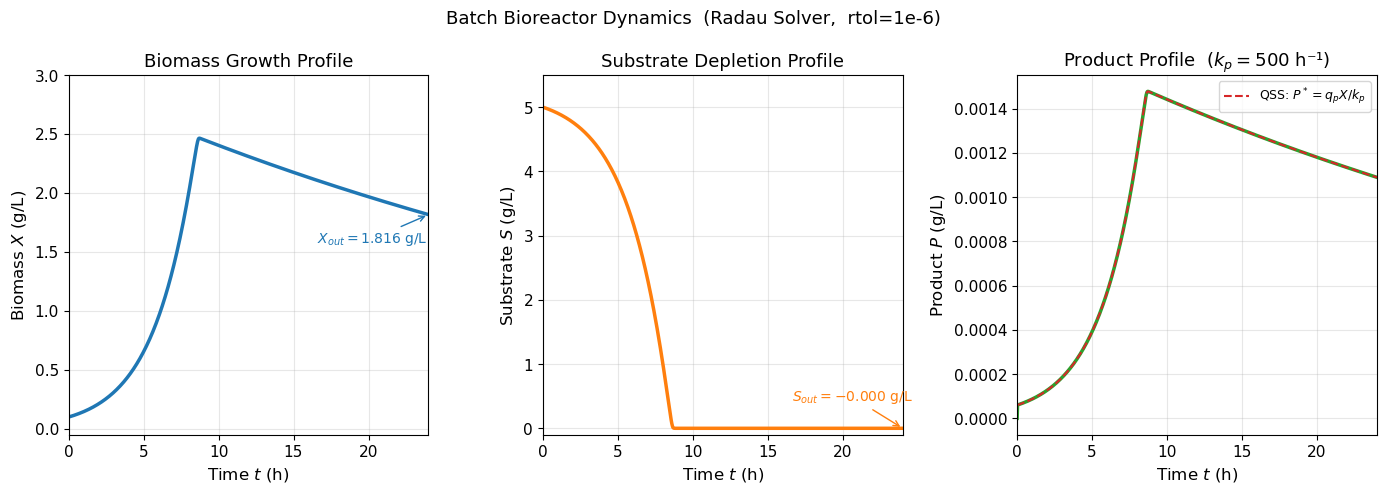


✓ 圖檔儲存：d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_03\figs\fig03_radau_solution.png


In [17]:
# ============================================================
# Radau / BDF / LSODA 剛性求解器比較
# ============================================================

solvers = ['Radau', 'BDF', 'LSODA']
results = {}

for method in solvers:
    t0 = time.perf_counter()
    sol = solve_ivp(
        fun=bioreactor_ode,
        t_span=(0, t_final),
        y0=y0,
        method=method,
        t_eval=t_eval,
        rtol=1e-6,
        atol=1e-9,
    )
    elapsed = time.perf_counter() - t0
    results[method] = {'sol': sol, 'time': elapsed}

# 參考解（高精度 Radau）
sol_ref = results['Radau']['sol']
X_ref = sol_ref.y[0, -1]
S_ref = sol_ref.y[1, -1]
P_ref = sol_ref.y[2, -1]

print("=" * 70)
print(f"{'求解器':<8}  {'nfev':>8}  {'njev':>6}  {'耗時(ms)':>9}  {'X_out':>8}  {'S_out':>8}  {'P_out':>10}")
print("-" * 70)

for method in solvers:
    r   = results[method]
    sol = r['sol']
    njev = getattr(sol, 'njev', 0)
    print(f"{method:<8}  {sol.nfev:>8,}  {njev:>6}  {r['time']*1000:>9.1f}  "
          f"{sol.y[0,-1]:>8.4f}  {sol.y[1,-1]:>8.4f}  {sol.y[2,-1]:>10.6f}")

# 與 RK45 標準設定比較
print(f"{'RK45':<8}  {sol_rk45.nfev:>8,}  {'N/A':>6}  {t_rk45*1000:>9.1f}  "
      f"  {sol_rk45.y[0,-1]:>8.4f}  {sol_rk45.y[1,-1]:>8.4f}  {sol_rk45.y[2,-1]:>10.6f}")
print("=" * 70)
print(f"\n→ 剛性求解器 Radau/BDF nfev 遠少於 RK45（~10-100 倍效率提升）")

# ============================================================
# 圖 3: Radau 求解的完整批次動態曲線
# ============================================================
sol_radau = results['Radau']['sol']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# --- X: Biomass ---
axes[0].plot(t_eval, sol_radau.y[0], color='tab:blue', lw=2.5)
axes[0].set_xlabel('Time $t$ (h)')
axes[0].set_ylabel('Biomass $X$ (g/L)')
axes[0].set_title('Biomass Growth Profile')
axes[0].set_xlim(0, t_final)
axes[0].set_ylim(-0.05, 3.0)
axes[0].annotate(f'$X_{{out}}={sol_radau.y[0,-1]:.3f}$ g/L',
                 xy=(t_final, sol_radau.y[0,-1]),
                 xytext=(-80, -20), textcoords='offset points',
                 fontsize=10, color='tab:blue',
                 arrowprops=dict(arrowstyle='->', color='tab:blue'))

# --- S: Substrate ---
axes[1].plot(t_eval, sol_radau.y[1], color='tab:orange', lw=2.5)
axes[1].set_xlabel('Time $t$ (h)')
axes[1].set_ylabel('Substrate $S$ (g/L)')
axes[1].set_title('Substrate Depletion Profile')
axes[1].set_xlim(0, t_final)
axes[1].set_ylim(-0.1, 5.5)
axes[1].annotate(f'$S_{{out}}={sol_radau.y[1,-1]:.3f}$ g/L',
                 xy=(t_final, sol_radau.y[1,-1]),
                 xytext=(-80, 20), textcoords='offset points',
                 fontsize=10, color='tab:orange',
                 arrowprops=dict(arrowstyle='->', color='tab:orange'))

# --- P: Product ---
axes[2].plot(t_eval, sol_radau.y[2], color='tab:green', lw=2.5)
axes[2].set_xlabel('Time $t$ (h)')
axes[2].set_ylabel('Product $P$ (g/L)')
axes[2].set_title('Product Profile  ($k_p=500$ h⁻¹)')
axes[2].set_xlim(0, t_final)

# 疊加準穩態理論值
P_qss = sol_radau.y[0] * q_p / k_p   # P ≈ qp*X/kp (quasi-steady-state)
axes[2].plot(t_eval, P_qss, color='tab:red', lw=1.5, ls='--',
             label='QSS: $P^* = q_p X / k_p$')
axes[2].legend(fontsize=9)

plt.suptitle('Batch Bioreactor Dynamics  (Radau Solver,  rtol=1e-6)', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig03_radau_solution.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"\n✓ 圖檔儲存：{FIG_DIR / 'fig03_radau_solution.png'}")

---
### 6. 容差參數靈敏度分析

`solve_ivp` 的精度由兩個容差參數控制：

- **`rtol`（相對容差）**：控制相對誤差，如 `rtol=1e-6` 表示每步相對誤差 $< 10^{-6}$
- **`atol`（絕對容差）**：控制狀態量接近 0 時的最低精度要求

對剛性求解器（`Radau`），改變 `rtol` 會影響：
1. 計算精度（出口濃度與高精度參考解的偏差）
2. 函數評估次數（`nfev`）

通常 `rtol=1e-6, atol=1e-9` 已足夠精確，更緊的容差（如 `1e-10`）回報遞減。

rtol          Radau nfev     RK45 nfev     Ratio   Radau err_X    RK45 err_X
--------------------------------------------------------------------------------
1e-03                327        25,496      78.0      4.50e-06      2.90e-13
1e-04                499        25,430      51.0      2.16e-07      2.94e-13
1e-05                751        25,418      33.8      3.02e-09      2.83e-13
1e-06              1,247        25,370      20.3      7.01e-10      3.94e-13
1e-07              1,917        25,340      13.2      2.02e-11      8.04e-14
1e-08              3,239        25,664       7.9      2.04e-12      2.33e-14


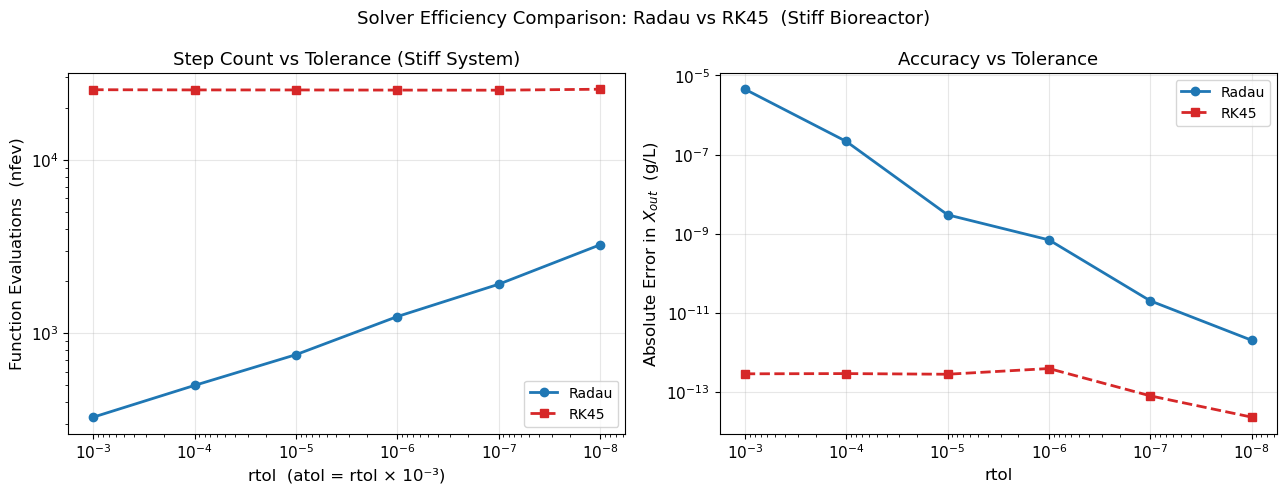


高精度參考解（Radau, rtol=1e-12）：X(24h) = 1.816357 g/L
✓ 圖檔儲存：d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_03\figs\fig04_tolerance_analysis.png


In [18]:
# ============================================================
# 容差參數靈敏度分析（Radau vs RK45）
# ============================================================

# 高精度參考解
sol_ref_hp = solve_ivp(
    fun=bioreactor_ode, t_span=(0, t_final), y0=y0,
    method='Radau', t_eval=t_eval, rtol=1e-12, atol=1e-14,
)
X_ref_end = sol_ref_hp.y[0, -1]
S_ref_end = sol_ref_hp.y[1, -1]

rtol_list = [1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8]

radau_nfev  = []
rk45_nfev   = []
radau_err_X = []
rk45_err_X  = []

for rtol_val in rtol_list:
    atol_val = rtol_val * 1e-3

    s_r = solve_ivp(fun=bioreactor_ode, t_span=(0, t_final), y0=y0,
                    method='Radau', t_eval=t_eval, rtol=rtol_val, atol=atol_val)
    s_k = solve_ivp(fun=bioreactor_ode, t_span=(0, t_final), y0=y0,
                    method='RK45',  t_eval=t_eval, rtol=rtol_val, atol=atol_val)

    radau_nfev.append(s_r.nfev)
    rk45_nfev.append(s_k.nfev)
    radau_err_X.append(abs(s_r.y[0, -1] - X_ref_end))
    rk45_err_X.append(abs(s_k.y[0, -1] - X_ref_end))

print(f"{'rtol':<10}  {'Radau nfev':>12}  {'RK45 nfev':>12}  {'Ratio':>8}  {'Radau err_X':>12}  {'RK45 err_X':>12}")
print("-" * 80)
for i, rv in enumerate(rtol_list):
    ratio = rk45_nfev[i] / radau_nfev[i]
    print(f"{rv:<10.0e}  {radau_nfev[i]:>12,}  {rk45_nfev[i]:>12,}  {ratio:>8.1f}  "
          f"{radau_err_X[i]:>12.2e}  {rk45_err_X[i]:>12.2e}")

# ============================================================
# 圖 4: 容差參數分析
# ============================================================
fig, (ax_nfev, ax_err) = plt.subplots(1, 2, figsize=(13, 5))

rtol_arr = np.array(rtol_list)

# nfev vs rtol
ax_nfev.loglog(rtol_arr, radau_nfev,  'o-', color='tab:blue',   lw=2, label='Radau')
ax_nfev.loglog(rtol_arr, rk45_nfev,   's--', color='tab:red',   lw=2, label='RK45')
ax_nfev.set_xlabel('rtol  (atol = rtol × 10⁻³)')
ax_nfev.set_ylabel('Function Evaluations  (nfev)')
ax_nfev.set_title('Step Count vs Tolerance (Stiff System)')
ax_nfev.legend()
ax_nfev.invert_xaxis()

# error vs rtol
ax_err.loglog(rtol_arr, radau_err_X, 'o-', color='tab:blue', lw=2, label='Radau')
ax_err.loglog(rtol_arr, rk45_err_X,  's--', color='tab:red', lw=2, label='RK45')
ax_err.set_xlabel('rtol')
ax_err.set_ylabel('Absolute Error in $X_{out}$  (g/L)')
ax_err.set_title('Accuracy vs Tolerance')
ax_err.legend()
ax_err.invert_xaxis()

plt.suptitle('Solver Efficiency Comparison: Radau vs RK45  (Stiff Bioreactor)', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig04_tolerance_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"\n高精度參考解（Radau, rtol=1e-12）：X(24h) = {X_ref_end:.6f} g/L")
print(f"✓ 圖檔儲存：{FIG_DIR / 'fig04_tolerance_analysis.png'}")

---
### 課程總結

#### 學習重點回顧

| 主題 | 說明 |
|------|------|
| **Stiff ODE 的識別** | 計算 Jacobian 特徵值：當 $SR = \max|\mathrm{Re}(\lambda_i)|/\min|\mathrm{Re}(\lambda_i)| \gg 1$，即為剛性系統 |
| **剛性來源** | 本例中 $k_p=500$ h $^{-1}$（產物降解快） $\gg \mu_{max}=0.4$ h $^{-1}$（細胞生長慢），SR $\approx 10^3$–$10^4$ |
| **RK45 的限制** | 顯式方法穩定域有限，剛性問題需 $h \lesssim 3.5/|\lambda_{max}| \approx 0.007$ h，nfev 爆增（~25 倍於 Radau）；放寬 `max_step` 亦無效 |
| **Radau/BDF 的優勢** | 隱式方法 A-stable，可採大步長；函數評估次數遠少於 RK45（本例 10–50 倍差距） |
| **容差的選擇** | `rtol=1e-6, atol=1e-9` 是一般化工問題的合理平衡；過緊容差回報遞減，過鬆則精度不足 |
| **準穩態近似（QSS）** | 快速組成（此處 $P$）往往快速趨近 $P^* = q_p X / k_p$，可視需要降維簡化模型 |

#### 物理意義

- **低剛性比值（SR < 100）**：任何求解器均可高效求解，`RK45` 是好選擇
- **高剛性比值（SR > 1000）**：必須使用 `Radau` 或 `BDF`，否則計算成本急劇上升
- **Monod 模型的特殊性**：在基質接近耗盡（ $S \to 0$）時，非線性使 $\partial \mu/\partial S$ 急劇上升，局部剛性比值可達 $10^4$

#### 延伸思考

1. 若移除產物方程（ $k_p$ 項），系統剛性如何變化？以 Jacobian 分析驗證
2. 在不同 $k_p$ 值（如 10、100、1000 h $^{-1}$）下，SR 與 RK45 nfev 的關係如何？
3. 如何利用**準穩態假設（QSS）**將三態系統簡化為兩態 ODE？誤差有多大？
4. 若批次反應改為**連續饋料（Fed-batch）**，ODE 右側需要如何修改？

> 以上問題詳見 Unit09_Example_04（BVP 觸媒反應管溫度分布）。
